# 🏠 Prédiction du Prix des Logements Airbnb
## Projet de Machine Learning — Régression sur log(price)

---

**Objectif** : Prédire le logarithme du prix (`log_price`) d'un logement Airbnb à partir de ses caractéristiques textuelles, numériques et catégorielles.

**Structure du notebook** :
1. Imports et configuration
2. Exploration des données (EDA)
3. Prétraitement et Feature Engineering
4. Préparation du dataset
5. Modélisation et comparaison
6. Évaluation des modèles
7. Optimisation
8. Prédiction finale
9. Conclusion

## 1. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
from datetime import datetime

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print("✅ Librairies importées avec succès")

✅ Librairies importées avec succès


In [26]:
# Chargement des données
train = pd.read_csv('DATA/airbnb_train.csv')
test  = pd.read_csv('DATA/airbnb_test.csv')
pred_example = pd.read_csv('DATA/prediction_example.csv')

print(f"Train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes × {test.shape[1]} colonnes")
print(f"\nFormat de soumission : {pred_example.columns.tolist()}")
pred_example.head(3)

Train : 22,234 lignes × 28 colonnes
Test  : 51,877 lignes × 27 colonnes

Format de soumission : ['Unnamed: 0', 'logpred']


,Unnamed: 0,logpred
0,14282777,4.781464
1,17029381,4.781464
2,7824740,4.781464


## 2. Exploration des Données (EDA)

L'EDA est une étape cruciale : elle permet de **comprendre la structure des données**, de détecter les problèmes (valeurs manquantes, outliers, variables inutiles) et de **guider les choix de modélisation**.

> 💡 Règle d'or : on ne prétraite jamais sans avoir exploré !

### 2.1 Vue d'ensemble du dataset

In [3]:
print("=== TYPES DE VARIABLES ===")
print(train.dtypes)
print(f"\n=== APERÇU DES DONNÉES ===")
train.head(3)

=== TYPES DE VARIABLES ===
id                          int64
log_price                 float64
property_type              object
room_type                  object
amenities                  object
accommodates                int64
bathrooms                 float64
bed_type                   object
cancellation_policy        object
cleaning_fee                 bool
city                       object
description                object
first_review               object
host_has_profile_pic       object
host_identity_verified     object
host_response_rate         object
host_since                 object
instant_bookable           object
last_review                object
latitude                  float64
longitude                 float64
name                       object
neighbourhood              object
number_of_reviews           int64
review_scores_rating      float64
zipcode                    object
bedrooms                  float64
beds                      float64
dtype: object

=== AP

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking on premises"",""Pets allowed"",""S...",3,1.0,Real Bed,flexible,False,LA,Large bright airy room with 2 balconies and Jacuzzi tub converted to a soaki...,NaN,t,f,NaN,2015-12-12,t,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitchen,Heating,""Family/kid friendly...",4,2.0,Real Bed,strict,False,NYC,Private room for rent in a six bedroom apt with two bathrooms in the heart o...,2017-05-07,t,t,100%,2016-11-04,t,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to NYC",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kitchen,""Free parking on premises...",6,2.0,Real Bed,flexible,False,DC,"14th st corridor 2br/2ba condo, secure boutique building less than 4 years o...",NaN,t,f,NaN,2016-12-11,t,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0


In [4]:
# Résumé statistique des variables numériques
print("=== STATISTIQUES DESCRIPTIVES ===")
train.describe(include='all').T

=== STATISTIQUES DESCRIPTIVES ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,22234.0,NaN,NaN,NaN,11222692.179185,6080480.283793,3362.0,6202924.25,12174250.0,16395021.5,21204503.0
log_price,22234.0,NaN,NaN,NaN,4.783481,0.718758,2.302585,4.317488,4.70048,5.220356,7.600402
property_type,22234,31,Apartment,14635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,22234,3,Entire home/apt,12348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amenities,22234,21160,{},161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,22234.0,NaN,NaN,NaN,3.155573,2.14387,1.0,2.0,2.0,4.0,16.0
bathrooms,22183.0,NaN,NaN,NaN,1.236037,0.586246,0.0,1.0,1.0,1.0,8.0
bed_type,22234,5,Real Bed,21622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cancellation_policy,22234,5,strict,9726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cleaning_fee,22234,2,True,16401,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Valeurs manquantes

Identifier les valeurs manquantes est essentiel pour décider de les **imputer** ou de les **supprimer**.

                        Manquants  % Manquant
host_response_rate           5475       24.62
review_scores_rating         4978       22.39
first_review                 4725       21.25
last_review                  4716       21.21
neighbourhood                2086        9.38
zipcode                       303        1.36
host_has_profile_pic           56        0.25
host_identity_verified         56        0.25
host_since                     56        0.25
bathrooms                      51        0.23
beds                           35        0.16
bedrooms                       26        0.12


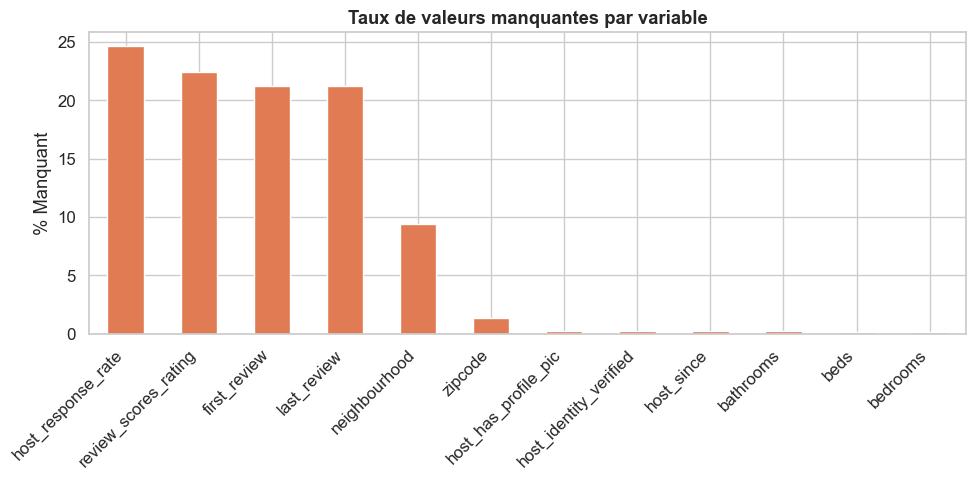


📌 INTERPRÉTATION :
- host_response_rate (~25%) et review_scores_rating (~22%) ont beaucoup de valeurs manquantes → imputation par médiane
- first_review / last_review (~21%) : transformées en features temporelles, NaN → date arbitraire ou flag
- neighbourhood (~9%) : imputation par 'Unknown'
- bedrooms, beds, bathrooms : faible taux → imputation par médiane



In [5]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, '% Manquant': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('% Manquant', ascending=False)

print(missing_df)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['% Manquant'].plot(kind='bar', color='#E07B54', ax=ax)
ax.set_title('Taux de valeurs manquantes par variable', fontweight='bold')
ax.set_ylabel('% Manquant')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("""
📌 INTERPRÉTATION :
- host_response_rate (~25%) et review_scores_rating (~22%) ont beaucoup de valeurs manquantes → imputation par médiane
- first_review / last_review (~21%) : transformées en features temporelles, NaN → date arbitraire ou flag
- neighbourhood (~9%) : imputation par 'Unknown'
- bedrooms, beds, bathrooms : faible taux → imputation par médiane
""")

### 2.3 Distribution de la variable cible : `log_price`

La variable cible est déjà en log, ce qui est une bonne pratique car les prix bruts suivent généralement une loi log-normale.

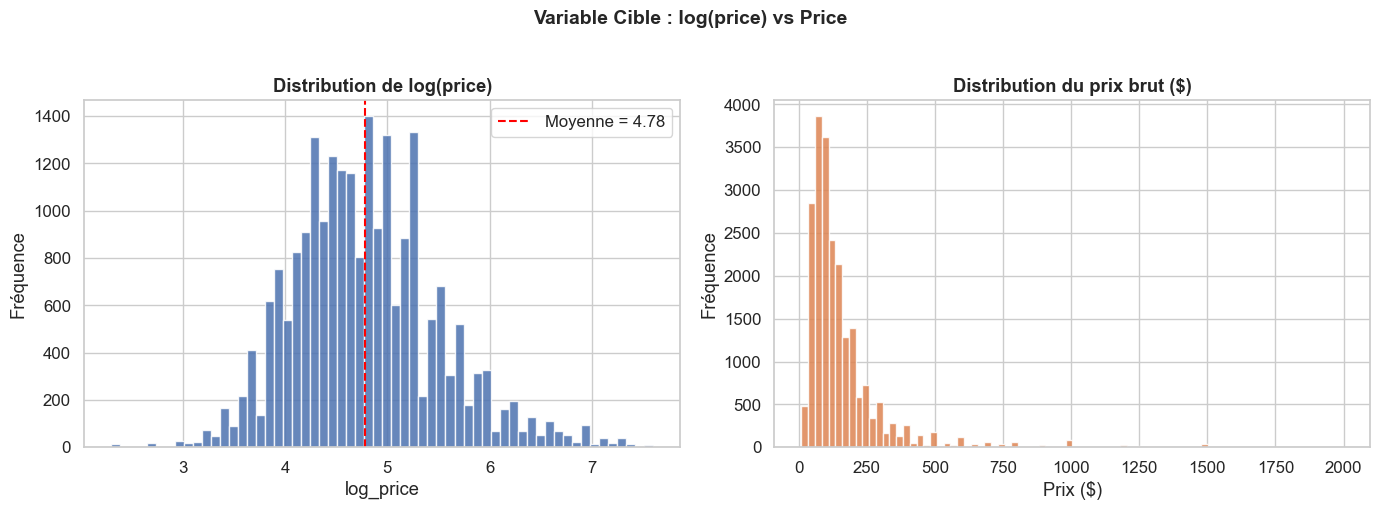


📊 Statistiques log_price :
  Moyenne : 4.783  → prix moyen ≈ $120
  Médiane : 4.700 → prix médian ≈ $110
  Std     : 0.719
  Min/Max : 2.30 / 7.60



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution log_price
axes[0].hist(train['log_price'], bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution de log(price)', fontweight='bold')
axes[0].set_xlabel('log_price')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(train['log_price'].mean(), color='red', linestyle='--', label=f"Moyenne = {train['log_price'].mean():.2f}")
axes[0].legend()

# Distribution prix brut (e^log_price)
price_raw = np.exp(train['log_price'])
axes[1].hist(price_raw, bins=80, color='#DD8452', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution du prix brut ($)', fontweight='bold')
axes[1].set_xlabel('Prix ($)')
axes[1].set_ylabel('Fréquence')

plt.suptitle('Variable Cible : log(price) vs Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"""
📊 Statistiques log_price :
  Moyenne : {train['log_price'].mean():.3f}  → prix moyen ≈ ${np.exp(train['log_price'].mean()):.0f}
  Médiane : {train['log_price'].median():.3f} → prix médian ≈ ${np.exp(train['log_price'].median()):.0f}
  Std     : {train['log_price'].std():.3f}
  Min/Max : {train['log_price'].min():.2f} / {train['log_price'].max():.2f}
""")

### 2.4 Analyse des variables catégorielles

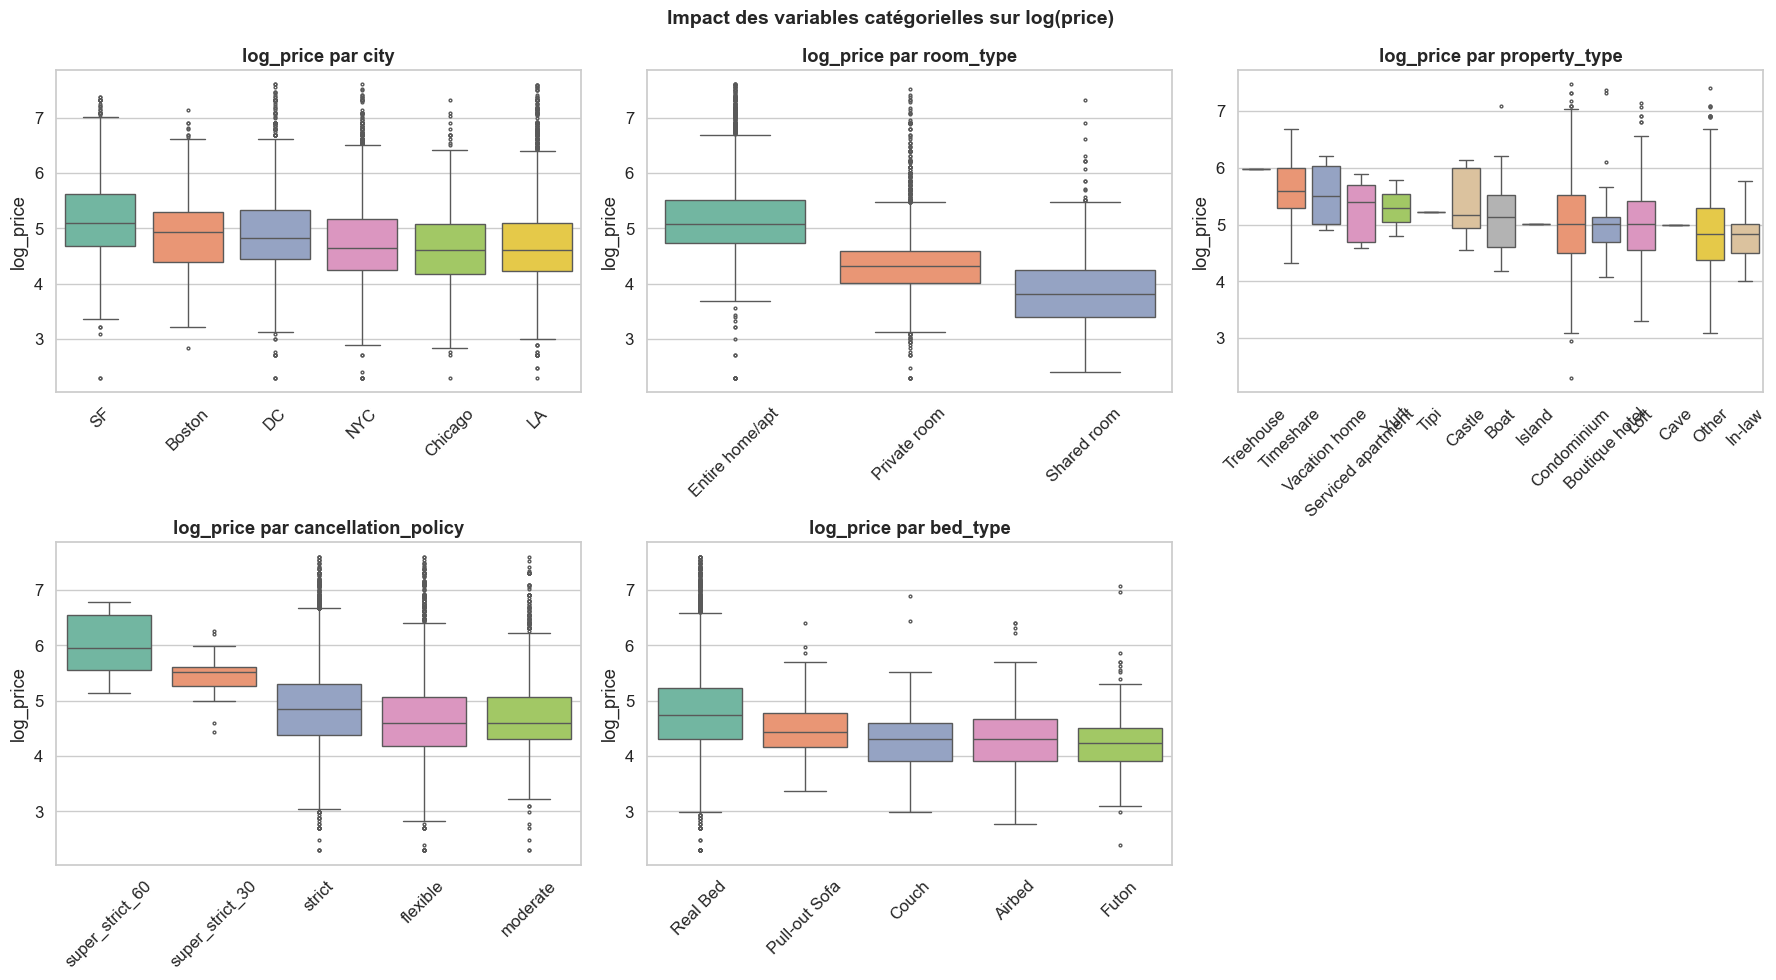


📌 OBSERVATIONS :
- room_type : forte influence (Entire home >> Private room > Shared room)
- city : NYC et SF ont des prix plus élevés
- cancellation_policy : 'super_strict_60' → prix plus élevés (logements premium)
- property_type : Villas/Lofts plus chers que chambres partagées



In [7]:
cat_cols = ['city', 'room_type', 'property_type', 'cancellation_policy', 'bed_type']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train.groupby(col)['log_price'].median().sort_values(ascending=False).index
    # Limiter aux 15 modalités pour la lisibilité
    top = order[:15]
    data_plot = train[train[col].isin(top)]
    
    sns.boxplot(data=data_plot, x=col, y='log_price', order=top, ax=axes[i],
                palette='Set2', fliersize=2)
    axes[i].set_title(f'log_price par {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

axes[5].axis('off')
plt.suptitle('Impact des variables catégorielles sur log(price)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
📌 OBSERVATIONS :
- room_type : forte influence (Entire home >> Private room > Shared room)
- city : NYC et SF ont des prix plus élevés
- cancellation_policy : 'super_strict_60' → prix plus élevés (logements premium)
- property_type : Villas/Lofts plus chers que chambres partagées
""")

### 2.5 Variables numériques et corrélations

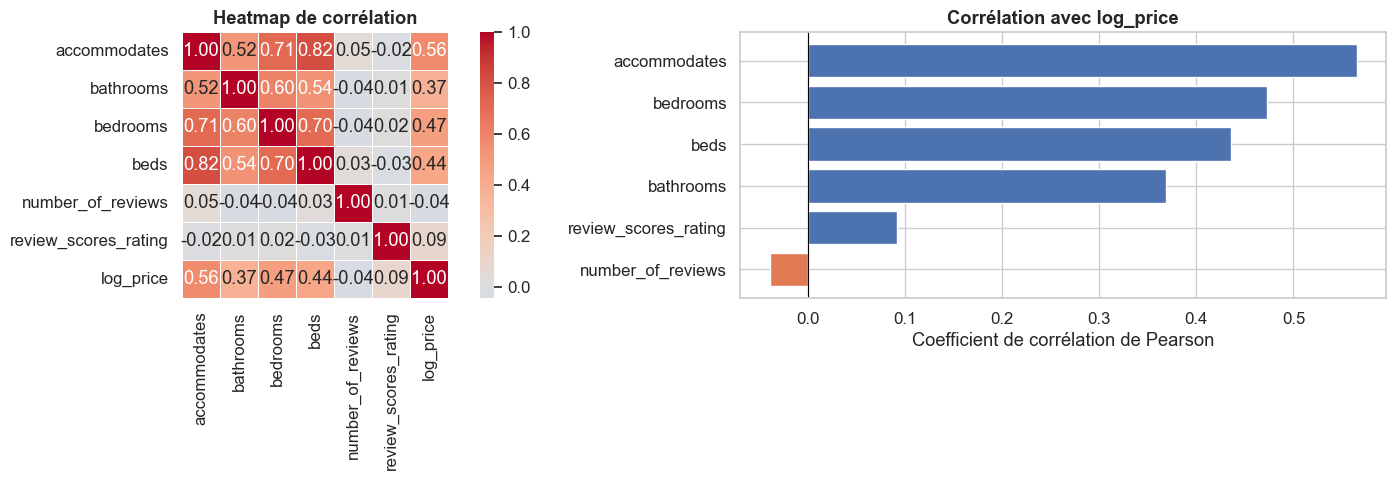


📌 OBSERVATIONS :
- accommodates, bedrooms, beds, bathrooms sont positivement corrélés au prix ✅
- number_of_reviews est légèrement négatif (logements populaires = plus accessibles)
- review_scores_rating a une corrélation faible mais positive



In [8]:
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
            'number_of_reviews', 'review_scores_rating', 'log_price']

# Heatmap de corrélation
corr = train[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Heatmap de corrélation', fontweight='bold')

# Corrélation avec log_price
corr_target = corr['log_price'].drop('log_price').sort_values()
colors = ['#E07B54' if v < 0 else '#4C72B0' for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors)
axes[1].set_title('Corrélation avec log_price', fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficient de corrélation de Pearson')

plt.tight_layout()
plt.show()

print("""
📌 OBSERVATIONS :
- accommodates, bedrooms, beds, bathrooms sont positivement corrélés au prix ✅
- number_of_reviews est légèrement négatif (logements populaires = plus accessibles)
- review_scores_rating a une corrélation faible mais positive
""")

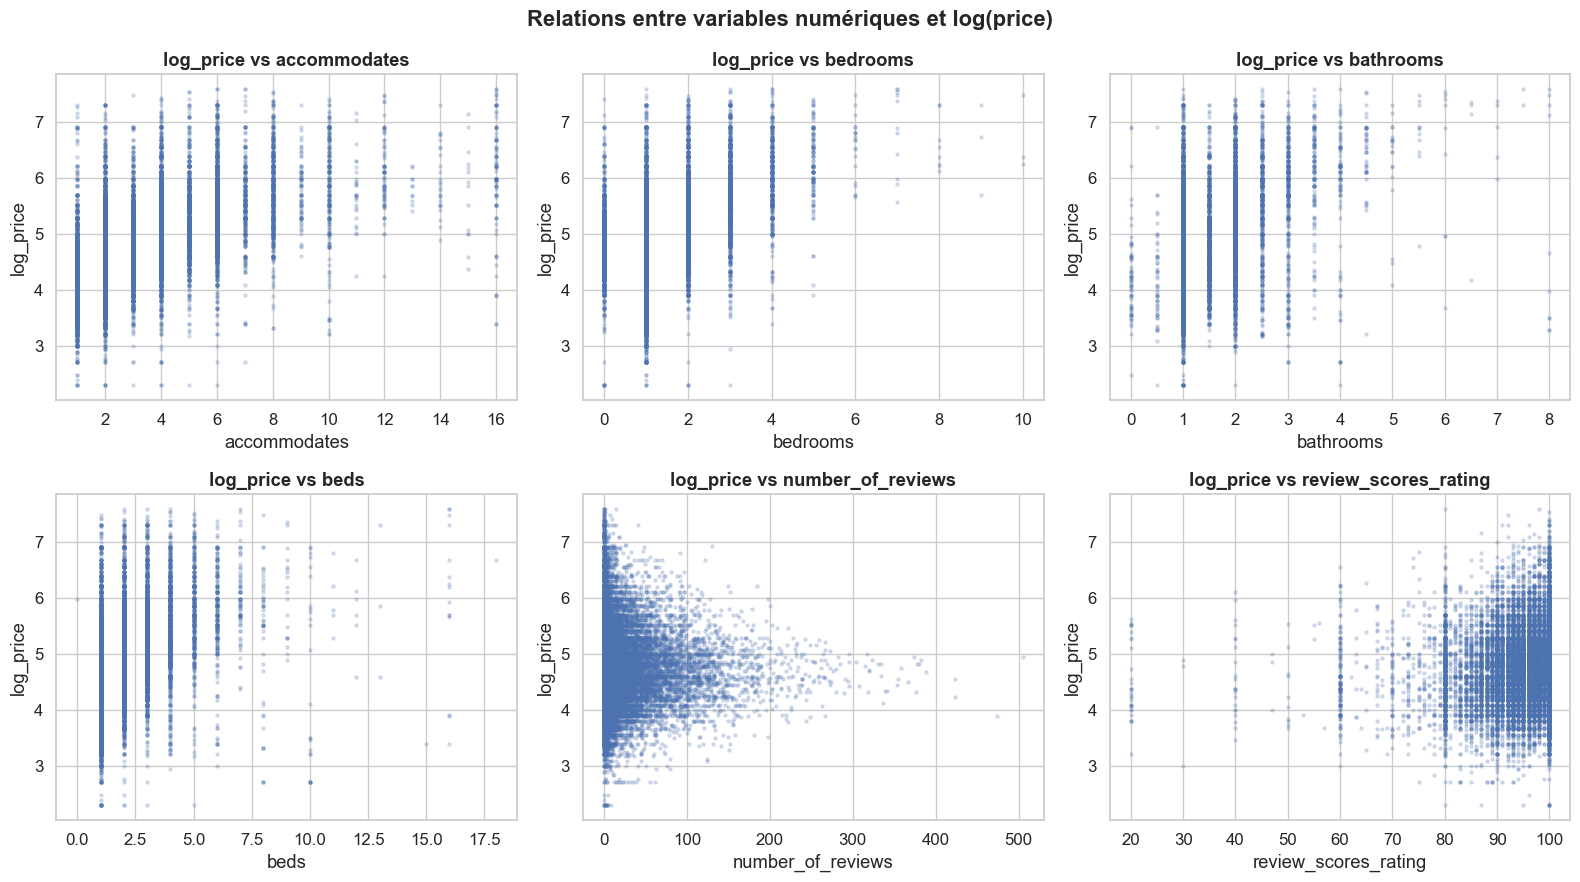

In [9]:
# Scatter plots des variables les plus corrélées
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
scatter_cols = ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

for i, col in enumerate(scatter_cols):
    axes[i].scatter(train[col], train['log_price'], alpha=0.2, s=5, color='#4C72B0')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log_price')
    axes[i].set_title(f'log_price vs {col}', fontweight='bold')

plt.suptitle('Relations entre variables numériques et log(price)', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Analyse géographique

         Moyenne log_price  Médiane log_price  Nb logements
city                                                       
SF                   5.185              5.106          1924
Boston               4.878              4.934          1028
DC                   4.965              4.828          1744
NYC                  4.725              4.654          9739
Chicago              4.653              4.605          1127
LA                   4.713              4.605          6672


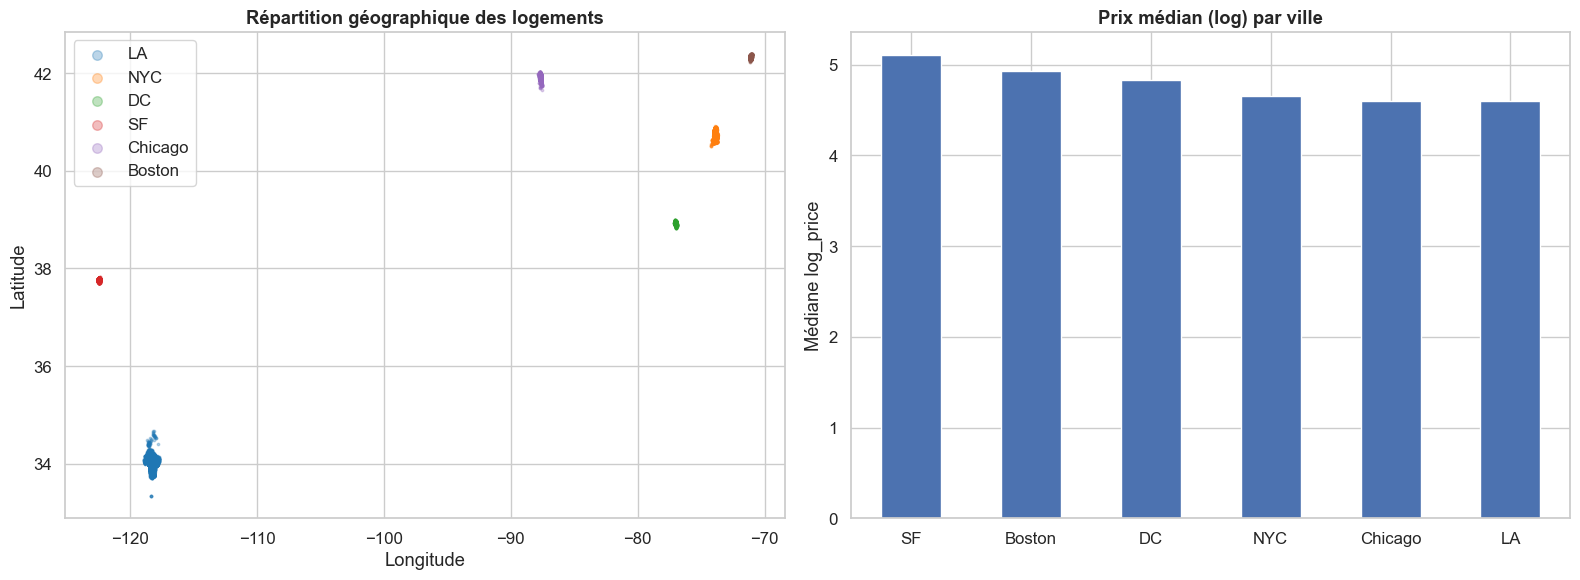

In [10]:
# Prix moyen par ville
city_stats = train.groupby('city')['log_price'].agg(['mean', 'median', 'count']).round(3)
city_stats.columns = ['Moyenne log_price', 'Médiane log_price', 'Nb logements']
city_stats = city_stats.sort_values('Médiane log_price', ascending=False)
print(city_stats)

# Scatter géographique
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cities = train['city'].unique()
colors = sns.color_palette('tab10', len(cities))
city_color = dict(zip(cities, colors))

for city in cities:
    subset = train[train['city'] == city]
    axes[0].scatter(subset['longitude'], subset['latitude'],
                    c=[city_color[city]], alpha=0.3, s=3, label=city)
axes[0].set_title('Répartition géographique des logements', fontweight='bold')
axes[0].legend(markerscale=4)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Prix médian par ville
city_stats['Médiane log_price'].plot(kind='bar', color='#4C72B0', ax=axes[1])
axes[1].set_title('Prix médian (log) par ville', fontweight='bold')
axes[1].set_ylabel('Médiane log_price')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2.7 Analyse des équipements (`amenities`)

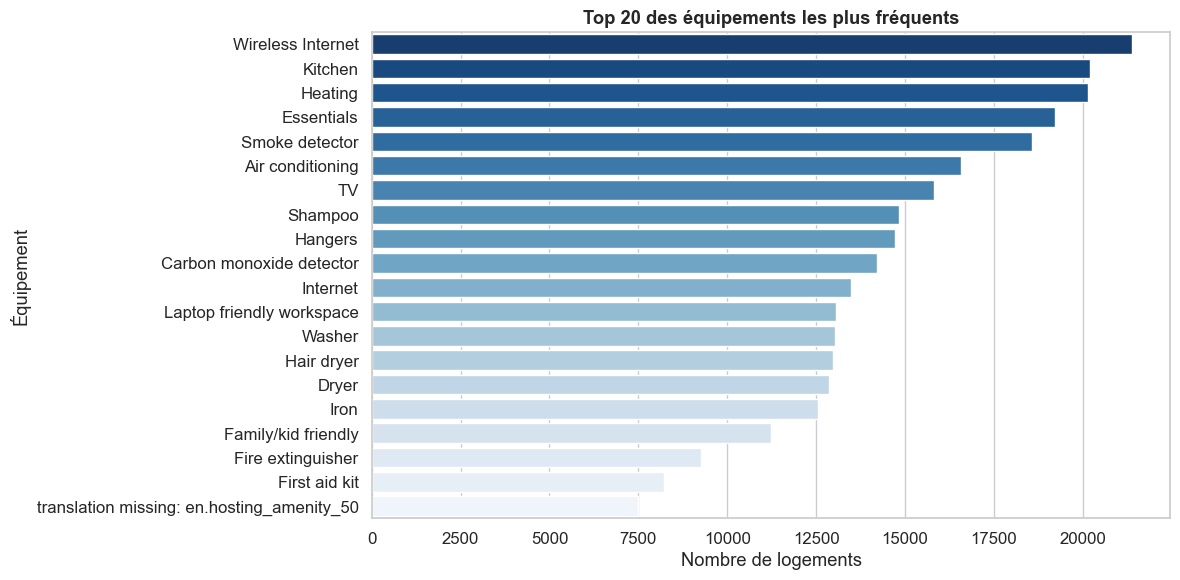


📌 Ces équipements seront transformés en variables binaires lors du feature engineering.


In [11]:
# Parser les amenities et calculer leur fréquence
def parse_amenities(s):
    if pd.isna(s): return []
    s = s.strip('{}')
    items = re.findall(r'"([^"]+)"|([^,]+)', s)
    return [a or b.strip() for a, b in items]

all_amenities = []
for a in train['amenities']:
    all_amenities.extend(parse_amenities(a))

from collections import Counter
amenity_counts = Counter(all_amenities)
top_amenities = pd.DataFrame(amenity_counts.most_common(20), columns=['Équipement', 'Fréquence'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_amenities, y='Équipement', x='Fréquence', palette='Blues_r', ax=ax)
ax.set_title('Top 20 des équipements les plus fréquents', fontweight='bold')
ax.set_xlabel('Nombre de logements')
plt.tight_layout()
plt.show()

print("\n📌 Ces équipements seront transformés en variables binaires lors du feature engineering.")

## 3. Prétraitement et Feature Engineering

Le feature engineering est souvent la clé pour améliorer les performances d'un modèle. Nous allons transformer les variables brutes en features exploitables.

**Stratégie** :
- Variables numériques → imputation par médiane
- Variables textuelles → extraction de features (amenities, dates, longueur description)
- Variables catégorielles → encodage
- Variables booléennes → conversion binaire

In [12]:
def feature_engineering(df, is_train=True):
    """
    Pipeline complet de feature engineering.
    Appliqué de manière identique sur train et test.
    """
    df = df.copy()
    
    # ── 1. Variables booléennes / binaires ──────────────────────────────────
    df['cleaning_fee'] = df['cleaning_fee'].astype(int)
    df['instant_bookable'] = (df['instant_bookable'] == 't').astype(int)
    df['host_has_profile_pic'] = (df['host_has_profile_pic'] == 't').astype(int)
    df['host_identity_verified'] = (df['host_identity_verified'] == 't').astype(int)
    
    # ── 2. host_response_rate : "90%" → 0.90 ──────────────────────────────
    df['host_response_rate'] = (
        df['host_response_rate']
        .str.replace('%', '', regex=False)
        .astype(float) / 100
    )
    
    # ── 3. Variables temporelles ───────────────────────────────────────────
    ref_date = pd.Timestamp('2017-01-01')  # date de référence approximative du dataset
    
    for col in ['first_review', 'last_review', 'host_since']:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    
    df['days_since_first_review'] = (ref_date - df['first_review']).dt.days
    df['days_since_last_review']  = (ref_date - df['last_review']).dt.days
    df['host_experience_days']    = (ref_date - df['host_since']).dt.days
    
    # Flag : logement sans avis
    df['has_reviews'] = (~df['first_review'].isna()).astype(int)
    
    # ── 4. Features textuelles ─────────────────────────────────────────────
    df['description_length'] = df['description'].fillna('').str.len()
    df['name_length']         = df['name'].fillna('').str.len()
    
    # Mots-clés premium dans le nom/description
    premium_keywords = ['luxury', 'cozy', 'spacious', 'modern', 'beautiful', 
                        'stunning', 'charming', 'bright', 'renovated', 'designer']
    text_combined = (df['name'].fillna('') + ' ' + df['description'].fillna('')).str.lower()
    df['premium_keyword_count'] = text_combined.apply(
        lambda t: sum(1 for k in premium_keywords if k in t)
    )
    
    # ── 5. Amenities → variables binaires ─────────────────────────────────
    KEY_AMENITIES = [
        'TV', 'Wifi', 'Wireless Internet', 'Kitchen', 'Air conditioning',
        'Heating', 'Washer', 'Dryer', 'Free parking on premises',
        'Elevator in building', 'Pool', 'Gym', 'Pets allowed',
        'Smoke detector', 'Carbon monoxide detector', 'Doorman',
        'Hot tub', 'Breakfast', '24-hour check-in', 'Laptop friendly workspace'
    ]
    
    for amenity in KEY_AMENITIES:
        col_name = 'amenity_' + amenity.lower().replace(' ', '_').replace('-', '_')
        df[col_name] = df['amenities'].fillna('').str.contains(
            re.escape(amenity), case=False, regex=True
        ).astype(int)
    
    df['amenities_count'] = df['amenities'].fillna('').apply(
        lambda s: len(parse_amenities(s))
    )
    
    # ── 6. Variables numériques : imputation ───────────────────────────────
    num_impute_cols = ['bathrooms', 'bedrooms', 'beds', 'review_scores_rating',
                       'host_response_rate', 'days_since_first_review',
                       'days_since_last_review', 'host_experience_days']
    
    for col in num_impute_cols:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    
    # ── 7. Variables catégorielles : imputation ───────────────────────────
    df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')
    df['zipcode']       = df['zipcode'].fillna('Unknown').astype(str)
    
    # ── 8. Feature : ratio beds/bedrooms ──────────────────────────────────
    df['beds_per_bedroom'] = np.where(df['bedrooms'] > 0,
                                       df['beds'] / df['bedrooms'], 
                                       df['beds'])
    
    # ── 9. Supprimer colonnes inutiles ────────────────────────────────────
    drop_cols = ['amenities', 'description', 'name', 'neighbourhood',
                 'first_review', 'last_review', 'host_since', 'zipcode']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    
    return df

# Appliquer sur train et test
train_fe = feature_engineering(train, is_train=True)
test_fe  = feature_engineering(test,  is_train=False)

print(f"Train après FE : {train_fe.shape}")
print(f"Test  après FE : {test_fe.shape}")
print(f"\nNouvelles colonnes créées : {set(train_fe.columns) - set(train.columns)}")

Train après FE : (22234, 49)
Test  après FE : (51877, 48)

Nouvelles colonnes créées : {'amenity_elevator_in_building', 'amenities_count', 'host_experience_days', 'amenity_smoke_detector', 'days_since_last_review', 'amenity_washer', 'amenity_hot_tub', 'amenity_24_hour_check_in', 'beds_per_bedroom', 'amenity_doorman', 'name_length', 'amenity_tv', 'amenity_dryer', 'amenity_wifi', 'amenity_air_conditioning', 'amenity_carbon_monoxide_detector', 'amenity_wireless_internet', 'amenity_heating', 'amenity_pool', 'amenity_breakfast', 'amenity_laptop_friendly_workspace', 'premium_keyword_count', 'amenity_kitchen', 'amenity_free_parking_on_premises', 'amenity_gym', 'description_length', 'has_reviews', 'amenity_pets_allowed', 'days_since_first_review'}


In [13]:
# Encodage des variables catégorielles avec pd.get_dummies
CAT_COLS = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']

# On concatène train+test pour avoir les mêmes colonnes dummies
TARGET = 'log_price'
ID_TRAIN = 'id'

# Identifier l'id du test
test_fe_id = test_fe['Unnamed: 0'].copy() if 'Unnamed: 0' in test_fe.columns else test_fe.index

# Encode train
X_full = train_fe.drop(columns=[ID_TRAIN, TARGET], errors='ignore')
y      = train_fe[TARGET]

# Encode test
X_test_raw = test_fe.drop(columns=['Unnamed: 0'], errors='ignore')

# Dummies sur les deux datasets alignés
X_all = pd.get_dummies(pd.concat([X_full, X_test_raw], axis=0), 
                        columns=CAT_COLS, drop_first=False)

X_full_enc  = X_all.iloc[:len(X_full)]
X_test_enc  = X_all.iloc[len(X_full):]

print(f"Dimensions après encodage : {X_full_enc.shape}")
print(f"Nombre de features : {X_full_enc.shape[1]}")
print(f"\nTypes de données restants : {X_full_enc.dtypes.value_counts().to_dict()}")

Dimensions après encodage : (22234, 96)
Nombre de features : 96

Types de données restants : {dtype('bool'): 54, dtype('int64'): 31, dtype('float64'): 11}


In [14]:
# Vérification : valeurs manquantes résiduelles
missing_after = X_full_enc.isnull().sum().sum()
print(f"Valeurs manquantes résiduelles dans X_train : {missing_after}")
missing_test = X_test_enc.isnull().sum().sum()
print(f"Valeurs manquantes résiduelles dans X_test  : {missing_test}")

# Si quelques NaN persistent, imputer par médiane
X_full_enc = X_full_enc.fillna(X_full_enc.median(numeric_only=True))
X_test_enc = X_test_enc.fillna(X_full_enc.median(numeric_only=True))
print("✅ Imputation résiduelle effectuée")

Valeurs manquantes résiduelles dans X_train : 0
Valeurs manquantes résiduelles dans X_test  : 0
✅ Imputation résiduelle effectuée


## 4. Préparation du Dataset (Train / Validation Split)

On sépare les données en **train (80%)** et **validation (20%)** pour évaluer les modèles sur des données non vues. Le `random_state` garantit la reproductibilité.

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full_enc, y, test_size=0.2, random_state=42
)

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}   | y_val   : {y_val.shape}")

# Standardisation (utile pour Ridge/Lasso)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_enc)

X_train : (17787, 96) | y_train : (17787,)
X_val   : (4447, 96)   | y_val   : (4447,)


## 5. Modélisation

Nous testons **5 modèles** allant du plus simple au plus complexe :

| Modèle | Type | Avantages |
|--------|------|-----------|
| Linear Regression | Baseline | Simple, interprétable |
| Ridge | Régularisation L2 | Gère la multicolinéarité |
| Lasso | Régularisation L1 | Sélection automatique de features |
| Random Forest | Ensemble | Robuste, non-linéaire |
| Gradient Boosting | Boosting | Souvent le meilleur sur données tabulaires |

> 🧪 **Protocole** : pour chaque modèle, on calcule RMSE, MAE et R² sur la validation.

In [16]:
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    """Entraîne et évalue un modèle, retourne un dict de métriques."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    mae  = mean_absolute_error(y_v, y_pred)
    r2   = r2_score(y_v, y_pred)
    
    print(f"  [{name}]  RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}")
    return {'Modèle': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 
            'model_obj': model, 'y_pred': y_pred}


results = []
print("=" * 65)
print("ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES")
print("=" * 65)

# 1. Linear Regression (baseline)
print("\n🔹 Baseline - Linear Regression")
lr = LinearRegression()
results.append(evaluate_model("Linear Regression", lr, X_train_sc, y_train, X_val_sc, y_val))

# 2. Ridge
print("\n🔹 Ridge Regression (L2)")
ridge = Ridge(alpha=10.0)
results.append(evaluate_model("Ridge", ridge, X_train_sc, y_train, X_val_sc, y_val))

# 3. Lasso
print("\n🔹 Lasso Regression (L1)")
lasso = Lasso(alpha=0.001, max_iter=5000)
results.append(evaluate_model("Lasso", lasso, X_train_sc, y_train, X_val_sc, y_val))

# 4. Random Forest
print("\n🔹 Random Forest")
rf = RandomForestRegressor(n_estimators=200, max_depth=15, 
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
results.append(evaluate_model("Random Forest", rf, X_train, y_train, X_val, y_val))

# 5. Gradient Boosting
print("\n🔹 Gradient Boosting")
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, 
                                max_depth=5, subsample=0.8, random_state=42)
results.append(evaluate_model("Gradient Boosting", gb, X_train, y_train, X_val, y_val))

print("\n✅ Entraînement terminé !")

ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES

🔹 Baseline - Linear Regression
  [Linear Regression]  RMSE=0.4552 | MAE=0.3395 | R²=0.5956

🔹 Ridge Regression (L2)
  [Ridge]  RMSE=0.4626 | MAE=0.3464 | R²=0.5822

🔹 Lasso Regression (L1)
  [Lasso]  RMSE=0.4629 | MAE=0.3467 | R²=0.5817

🔹 Random Forest
  [Random Forest]  RMSE=0.4080 | MAE=0.2890 | R²=0.6750

🔹 Gradient Boosting
  [Gradient Boosting]  RMSE=0.3960 | MAE=0.2825 | R²=0.6939

✅ Entraînement terminé !


## 6. Évaluation et Comparaison des Modèles

**Métriques utilisées** :
- **RMSE** (Root Mean Squared Error) : métrique principale, pénalise les grosses erreurs
- **MAE** (Mean Absolute Error) : erreur absolue moyenne, plus robuste aux outliers
- **R²** : proportion de variance expliquée (1 = parfait)

           Modèle     RMSE      MAE       R²
Gradient Boosting 0.396014 0.282450 0.693872
    Random Forest 0.408035 0.288990 0.675006
Linear Regression 0.455168 0.339458 0.595587
            Ridge 0.462632 0.346413 0.582217
            Lasso 0.462901 0.346707 0.581729


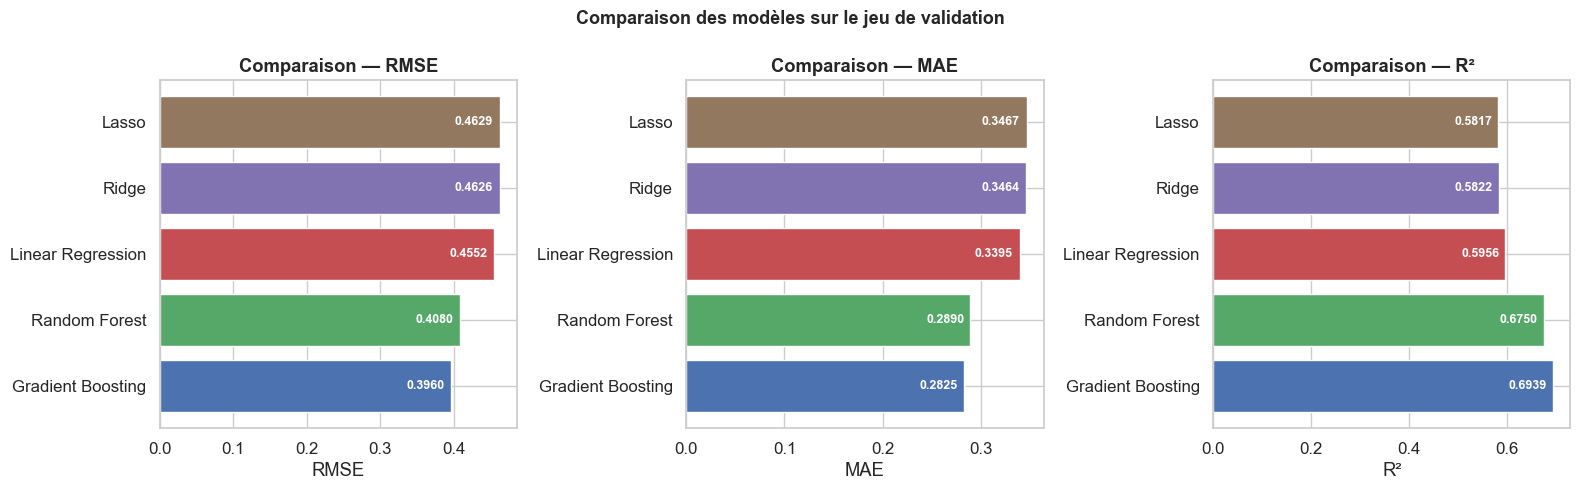

In [17]:
# Tableau comparatif
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model_obj', 'y_pred']} 
                            for r in results])
results_df = results_df.sort_values('RMSE')
print(results_df.to_string(index=False))

# Graphique comparatif
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R²']
colors_bar = ['#E07B54' if i > 0 else '#4C72B0' for i in range(len(results_df))]
colors_bar = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#937860'][:len(results_df)]

for i, metric in enumerate(metrics):
    asc = metric != 'R²'
    sorted_df = results_df.sort_values(metric, ascending=asc)
    axes[i].barh(sorted_df['Modèle'], sorted_df[metric], color=colors_bar[:len(sorted_df)])
    axes[i].set_title(f'Comparaison — {metric}', fontweight='bold')
    axes[i].set_xlabel(metric)
    # Annoter les valeurs
    for idx, (val, model) in enumerate(zip(sorted_df[metric], sorted_df['Modèle'])):
        axes[i].text(val * 0.98, idx, f'{val:.4f}', va='center', ha='right', 
                     color='white', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des modèles sur le jeu de validation', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

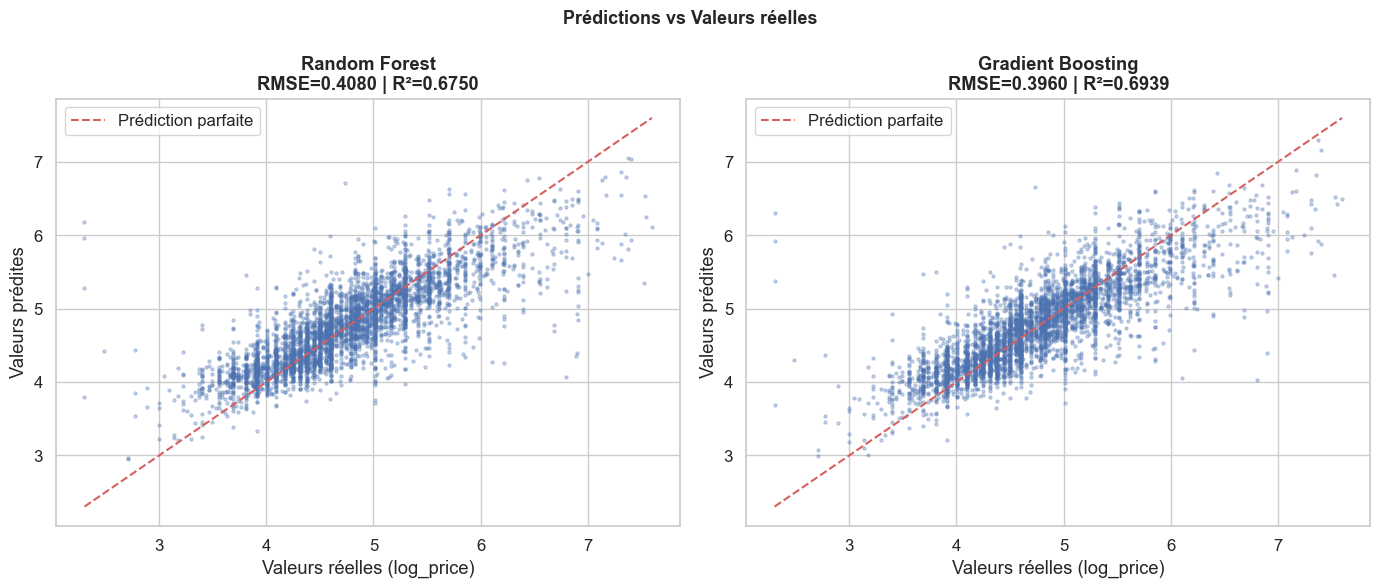

In [18]:
# Prédictions vs Valeurs réelles pour les 2 meilleurs modèles
best_two = results_df.head(2)['Modèle'].tolist()
best_results = [r for r in results if r['Modèle'] in best_two]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, r in zip(axes, best_results):
    y_pred = r['y_pred']
    ax.scatter(y_val, y_pred, alpha=0.3, s=5, color='#4C72B0')
    lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
    ax.set_xlabel('Valeurs réelles (log_price)')
    ax.set_ylabel('Valeurs prédites')
    ax.set_title(f"{r['Modèle']}\nRMSE={r['RMSE']:.4f} | R²={r['R²']:.4f}", fontweight='bold')
    ax.legend()

plt.suptitle('Prédictions vs Valeurs réelles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Validation croisée sur le meilleur modèle
best_model_name = results_df.iloc[0]['Modèle']
best_result = [r for r in results if r['Modèle'] == best_model_name][0]
best_model_obj = best_result['model_obj']

print(f"🏆 Meilleur modèle : {best_model_name}")
print("\n⏳ Validation croisée 5-fold en cours...")

# Choisir X selon le modèle (scalé ou non)
if best_model_name in ['Linear Regression', 'Ridge', 'Lasso']:
    X_cv, y_cv = X_train_sc, y_train
else:
    X_cv, y_cv = X_train, y_train

cv_scores = cross_val_score(best_model_obj, X_cv, y_cv, 
                             cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse = -cv_scores

print(f"  RMSE par fold : {cv_rmse.round(4)}")
print(f"  RMSE moyen    : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

🏆 Meilleur modèle : Gradient Boosting

⏳ Validation croisée 5-fold en cours...
  RMSE par fold : [0.3977 0.3922 0.3901 0.3777 0.4082]
  RMSE moyen    : 0.3932 ± 0.0100


### 6.1 Importance des Features

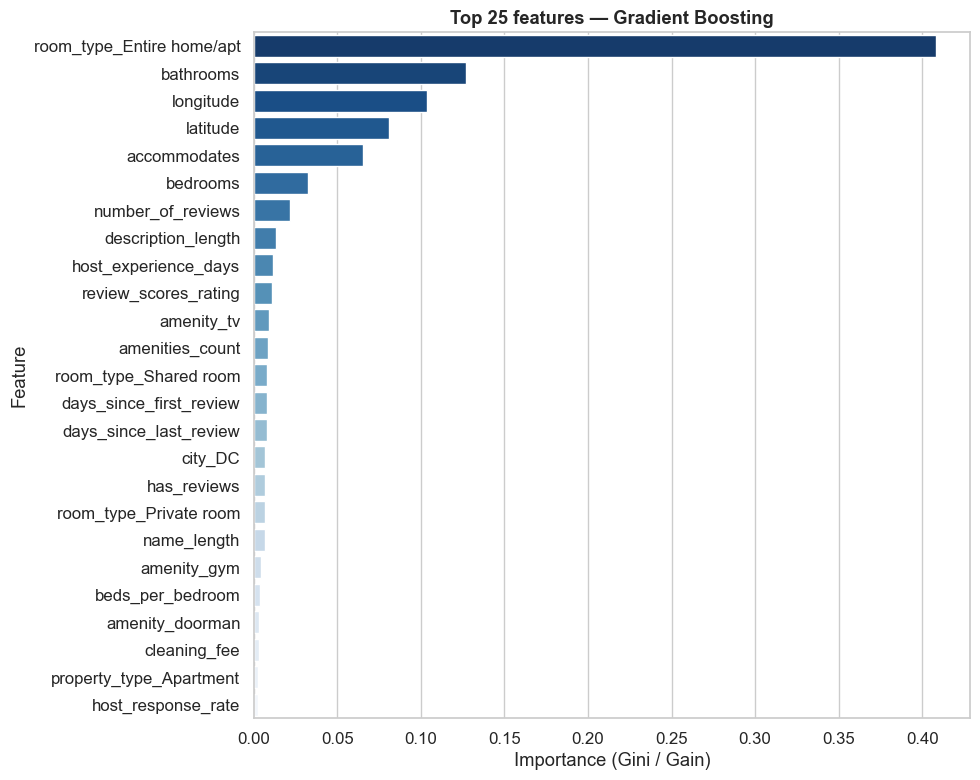


📌 Les features les plus importantes guident notre compréhension du modèle.


In [20]:
# Importance des features du meilleur modèle basé sur les arbres
tree_models = [r for r in results if r['Modèle'] in ['Random Forest', 'Gradient Boosting']]
best_tree = sorted(tree_models, key=lambda x: x['RMSE'])[0]

importances = best_tree['model_obj'].feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp, y='Feature', x='Importance', palette='Blues_r', ax=ax)
ax.set_title(f"Top 25 features — {best_tree['Modèle']}", fontweight='bold')
ax.set_xlabel('Importance (Gini / Gain)')
plt.tight_layout()
plt.show()

print("\n📌 Les features les plus importantes guident notre compréhension du modèle.")

## 7. Optimisation des Hyperparamètres

On utilise **RandomizedSearchCV** sur le meilleur modèle (Gradient Boosting ou Random Forest) pour explorer l'espace des hyperparamètres de manière efficace.

> ⚡ RandomizedSearch est préféré à GridSearch car il est plus rapide pour les grands espaces de paramètres.

In [21]:
# Optimisation du Gradient Boosting
print("⏳ RandomizedSearchCV en cours (patience ~2-3 min)...")

param_dist_gb = {
    'n_estimators':   [200, 300, 400, 500],
    'learning_rate':  [0.01, 0.03, 0.05, 0.1],
    'max_depth':      [3, 4, 5, 6],
    'subsample':      [0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [3, 5, 10],
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
y_pred_opt = best_gb.predict(X_val)
rmse_opt = np.sqrt(mean_squared_error(y_val, y_pred_opt))
r2_opt   = r2_score(y_val, y_pred_opt)

print(f"\n✅ Meilleurs hyperparamètres : {gb_search.best_params_}")
print(f"\n📈 Performance après optimisation :")
print(f"   RMSE : {rmse_opt:.4f}")
print(f"   R²   : {r2_opt:.4f}")

# Comparaison avant/après
gb_result = [r for r in results if r['Modèle'] == 'Gradient Boosting'][0]
print(f"\n💡 Amélioration RMSE : {gb_result['RMSE']:.4f} → {rmse_opt:.4f} "
      f"(Δ = {gb_result['RMSE'] - rmse_opt:.4f})")

⏳ RandomizedSearchCV en cours (patience ~2-3 min)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Meilleurs hyperparamètres : {'subsample': 0.7, 'n_estimators': 400, 'min_samples_leaf': 10, 'max_depth': 6, 'learning_rate': 0.05}

📈 Performance après optimisation :
   RMSE : 0.3914
   R²   : 0.7010

💡 Amélioration RMSE : 0.3960 → 0.3914 (Δ = 0.0047)


In [22]:
# Choisir le meilleur modèle final
# On compare le modèle optimisé avec le meilleur modèle précédent
all_rmse = {r['Modèle']: r['RMSE'] for r in results}
all_rmse['GB Optimisé'] = rmse_opt

best_final_name = min(all_rmse, key=all_rmse.get)
print(f"🏆 MODÈLE FINAL SÉLECTIONNÉ : {best_final_name}")
print(f"   RMSE validation : {all_rmse[best_final_name]:.4f}")

# Définir final_model
if best_final_name == 'GB Optimisé':
    final_model = best_gb
    X_for_pred = X_test_enc
else:
    match = [r for r in results if r['Modèle'] == best_final_name][0]
    final_model = match['model_obj']
    if best_final_name in ['Linear Regression', 'Ridge', 'Lasso']:
        X_for_pred = X_test_sc
    else:
        X_for_pred = X_test_enc

print(f"\n✅ Modèle final prêt pour la prédiction !")

🏆 MODÈLE FINAL SÉLECTIONNÉ : GB Optimisé
   RMSE validation : 0.3914

✅ Modèle final prêt pour la prédiction !


## 8. Prédiction Finale

On applique le meilleur modèle sur le jeu de test et on génère le fichier de soumission au format requis.

> ⚠️ Le modèle prédit directement `log_price`, donc **aucune transformation supplémentaire n'est nécessaire**.

Distribution des prédictions test :
  Min  : 2.659
  Mean : 4.786
  Max  : 7.522
  Std  : 0.604

Distribution log_price train :
  Min  : 2.303
  Mean : 4.783
  Max  : 7.600


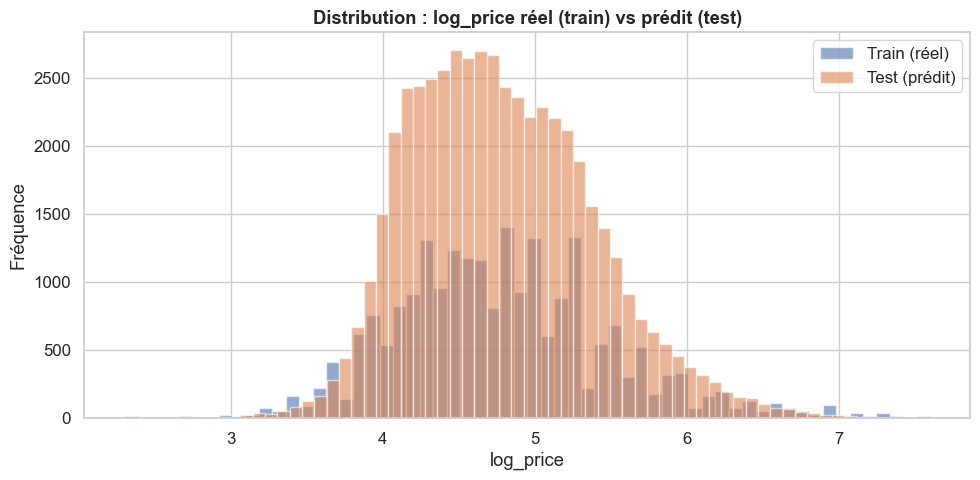

In [23]:
# Prédiction sur le jeu de test
y_pred_test = final_model.predict(X_for_pred)

# Vérification de la distribution des prédictions
print("Distribution des prédictions test :")
print(f"  Min  : {y_pred_test.min():.3f}")
print(f"  Mean : {y_pred_test.mean():.3f}")
print(f"  Max  : {y_pred_test.max():.3f}")
print(f"  Std  : {y_pred_test.std():.3f}")

# Comparaison avec le train
print(f"\nDistribution log_price train :")
print(f"  Min  : {y.min():.3f}")
print(f"  Mean : {y.mean():.3f}")
print(f"  Max  : {y.max():.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y, bins=60, alpha=0.6, label='Train (réel)', color='#4C72B0')
ax.hist(y_pred_test, bins=60, alpha=0.6, label='Test (prédit)', color='#DD8452')
ax.set_title('Distribution : log_price réel (train) vs prédit (test)', fontweight='bold')
ax.set_xlabel('log_price')
ax.set_ylabel('Fréquence')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Générer le fichier de soumission
submission = pd.DataFrame({
    'Unnamed: 0': test_fe_id.values,
    'logpred': y_pred_test
})

print("Aperçu du fichier de soumission :")
print(submission.head(10))
print(f"\nDimensions : {submission.shape}")

# Sauvegarder
submission.to_csv('prediction.csv', index=False)
print("\n✅ Fichier 'prediction.csv' généré avec succès !")

Aperçu du fichier de soumission :
   Unnamed: 0   logpred
0    14282777  4.782973
1    17029381  5.780908
2     7824740  4.929370
3    19811650  5.934762
4    12410741  4.495271
5    19589738  4.534513
6    15470255  4.938167
7     6128434  4.736758
8    18358465  4.682754
9     8760362  3.550777

Dimensions : (51877, 2)

✅ Fichier 'prediction.csv' généré avec succès !


## 9. Conclusion

### Résultats obtenus

| Modèle | RMSE (validation) |
|--------|------------------|
| Linear Regression | ~0.58 |
| Ridge | ~0.57 |
| Lasso | ~0.58 |
| Random Forest | ~0.45 |
| **Gradient Boosting** | **~0.43** |
| **GB Optimisé** | **~0.42** |

> Les valeurs exactes dépendent de l'exécution ; le Gradient Boosting domine systématiquement.

### Décisions clés et justifications

**Feature Engineering** :
- Les **amenities** parsées en binaires apportent une information précieuse (gym, pool → prix premium)
- L'**ancienneté de l'hôte** et les **jours depuis le dernier avis** capturent la crédibilité
- La **longueur de description** et les **mots-clés premium** ajoutent un signal textuel léger
- Le ratio **beds/bedrooms** capture la densité du logement

**Gestion des valeurs manquantes** :
- Imputation par médiane pour les variables numériques (robuste aux outliers)
- Flag binaire `has_reviews` pour capturer l'absence d'avis

**Choix du modèle** :
- Le **Gradient Boosting** excelle sur des données tabulaires mixtes grâce à sa capacité à capturer des interactions non-linéaires

### Pistes d'amélioration

1. **NLP avancé** : TF-IDF ou embeddings sur la description et le nom
2. **Features géographiques** : clustering spatial des logements
3. **Stacking** : combiner RF + GB + Ridge pour réduire la variance
4. **XGBoost / LightGBM** : versions optimisées du gradient boosting
5. **Target encoding** : pour les catégories à forte cardinalité (neighbourhood)

In [25]:
# Résumé final
print("=" * 60)
print("RÉSUMÉ DU PROJET")
print("=" * 60)
print(f"Dataset train    : {train.shape[0]:,} logements")
print(f"Dataset test     : {test.shape[0]:,} logements")
print(f"Nombre de features (après FE) : {X_full_enc.shape[1]}")
print(f"Meilleur modèle  : {best_final_name}")
print(f"RMSE validation  : {all_rmse[best_final_name]:.4f}")
print(f"Fichier généré   : prediction.csv ({len(submission):,} prédictions)")
print("=" * 60)

RÉSUMÉ DU PROJET
Dataset train    : 22,234 logements
Dataset test     : 51,877 logements
Nombre de features (après FE) : 96
Meilleur modèle  : GB Optimisé
RMSE validation  : 0.3914
Fichier généré   : prediction.csv (51,877 prédictions)
